# 08 — Spartan Arena validation

Load the richest arena run on disk, audit that the artifact pipeline produced
everything we expect, and visualise what a reviewer cares about.

**What this notebook now covers (beyond the original equity + cross-modal plots):**

* **Attribution coverage audit** — what fraction of decisions actually carry
  populated `tft_vsn_top` / `gat_edges_top` / `llm_top_tokens` (and an honest
  read when a run predates them).
* **Super-state latent geometry** — load every `states/<traj>/<step>.npy`
  (260-d) and chart the trajectories' paths through PCA / t-SNE space, where
  divergence is visible directly.
* **Action-kind transition matrix** — the agent's behavioural dynamics.
* **Counterfactual / BC dataset** — action *and* sample-weight distributions and
  where the "good-action" states sit in latent space.
* The original **reward attribution**, **divergence proxy**, **run summary** and
  **schema assertions**, kept and tightened.

**Prerequisite.** At least one arena run must exist. The fastest way to make one:

```bash
python scripts/run_arena.py --ticker AAPL --start 2024-01-01 --end 2024-01-02 \
    --n-trajectories 3 --n-steps 50 --output-dir ./artifacts/arena
```

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from backend.config.settings import get_settings
from backend.simulation.arena.schemas import ArenaRunMetadata, DecisionRecord
from backend.simulation.xai.run_summarizer import summarize_run

plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#ab47bc",
    "neutral": "#B0BEC5",
}

## 1. Locate the richest run

Resolve the artifact root relative to the project root (not the CWD), then pick
the run with the **most decisions that also has super-states on disk** — the one
that exercises the most of the pipeline.

In [2]:
project_root = Path.cwd()
while not (project_root / "pyproject.toml").exists() and project_root != project_root.parent:
    project_root = project_root.parent
settings_dir = Path(get_settings().arena.artifact_dir)
artifact_root = (
    settings_dir if settings_dir.is_absolute() else project_root / settings_dir
).resolve()
print("Looking under:", artifact_root)


def run_score(p: Path) -> int:
    if not (p / "decisions.jsonl").exists():
        return -1
    n = sum(1 for _ in (p / "decisions.jsonl").open())
    has_states = (p / "states").is_dir() and any((p / "states").rglob("*.npy"))
    return n + (10_000 if has_states else 0)


runs = [p for p in artifact_root.iterdir() if p.is_dir() and (p / "decisions.jsonl").exists()]
assert runs, f"No runs under {artifact_root}. Run scripts/run_arena.py first."
latest = max(runs, key=run_score)
print(f"Selected run: {latest.name}")
print(f"  decisions : {sum(1 for _ in (latest / 'decisions.jsonl').open())}")
print(f"  states/   : {'present' if (latest / 'states').is_dir() else 'absent'}")

Looking under: /home/pyros05/Escritorio/lumina_project/artifacts/arena
Selected run: 53b7ec94-434e-42dd-a870-ccdabeaef699
  decisions : 1990
  states/   : present


## 2. Load & validate decision records

Each line of `decisions.jsonl` is validated against the Pydantic `DecisionRecord`
schema as it loads — the contract every downstream consumer relies on.

In [3]:
records: list[DecisionRecord] = []
with (latest / "decisions.jsonl").open(encoding="utf-8") as fh:
    for line in fh:
        records.append(DecisionRecord.model_validate_json(line))
print(
    f"Loaded {len(records)} decisions across {len({r.trajectory_id for r in records})} trajectories"
)
counts = pd.Series([r.trajectory_id for r in records]).value_counts().sort_index()
print("decisions per trajectory:", counts.to_dict())

Loaded 1990 decisions across 10 trajectories
decisions per trajectory: {0: 199, 1: 199, 2: 199, 3: 199, 4: 199, 5: 199, 6: 199, 7: 199, 8: 199, 9: 199}


## 3. Flatten to a DataFrame

In [4]:
df = pd.DataFrame(
    [
        {
            "trajectory_id": r.trajectory_id,
            "step_index": r.step_index,
            "action_kind": r.action_kind.value,
            "direction": r.action_vector[0],
            "urgency": r.action_vector[1],
            "sizing": r.action_vector[2],
            "stop": r.action_vector[3],
            "confidence": r.confidence,
            "uncertainty": r.uncertainty,
            "realized_reward": r.realized_reward or 0.0,
            "cm_price": r.attribution.cross_modal.price,
            "cm_news": r.attribution.cross_modal.news,
            "cm_graph": r.attribution.cross_modal.graph,
            "n_vsn": len(r.attribution.tft_vsn_top),
            "n_gat": len(r.attribution.gat_edges_top),
            "n_tokens": 0
            if r.attribution.llm_top_tokens is None
            else len(r.attribution.llm_top_tokens),
        }
        for r in records
    ]
)
print("DataFrame:", df.shape)
df.head()

DataFrame: (1990, 16)


,trajectory_id,step_index,action_kind,direction,urgency,sizing,stop,confidence,uncertainty,realized_reward,cm_price,cm_news,cm_graph,n_vsn,n_gat,n_tokens
0,0,0,HOLD,0.132581,0.743722,0.215997,0.619711,0.565948,0.434052,-1.000000,0.333333,0.333333,0.333333,0,0,0
1,1,0,HOLD,0.308321,-0.285969,-0.262410,0.689721,0.515224,0.484776,-0.320764,0.333333,0.333333,0.333333,0,0,0
2,2,0,HOLD,-0.030981,0.282136,0.224216,0.321457,0.489156,0.510844,-1.000000,0.333333,0.333333,0.333333,0,0,0
3,3,0,HOLD,0.417919,0.460579,0.283218,0.513808,0.510569,0.489431,-1.000000,0.333333,0.333333,0.333333,0,0,0
4,4,0,HOLD,-0.083329,0.254163,0.099835,0.193734,0.421554,0.578446,-1.000000,0.333333,0.333333,0.333333,0,0,0


## 4. Attribution-coverage audit

The `AttributionPayload` can carry TFT VSN weights, GAT edge coefficients and LLM
token importances. We report how often each is actually populated. (These early
runs were produced by an untrained pipeline, so the deep-attribution channels are
empty and the cross-modal weights are uniform — we surface that honestly rather
than pretend otherwise.)

In [5]:
cov = {
    "cross_modal (non-uniform)": float(
        (df[["cm_price", "cm_news", "cm_graph"]].std(axis=1) > 1e-6).mean()
    ),
    "tft_vsn_top populated": float((df["n_vsn"] > 0).mean()),
    "gat_edges_top populated": float((df["n_gat"] > 0).mean()),
    "llm_top_tokens populated": float((df["n_tokens"] > 0).mean()),
}
for k, v in cov.items():
    print(f"  {v:6.1%}  {k}")

# If VSN/GAT attributions exist, aggregate the most-cited features/edges.
vsn_counter, gat_counter = {}, {}
for r in records:
    for w in r.attribution.tft_vsn_top:
        vsn_counter[w.feature] = vsn_counter.get(w.feature, 0.0) + w.weight
    for e in r.attribution.gat_edges_top:
        key = f"{e.source_ticker}->{e.target_ticker}"
        gat_counter[key] = gat_counter.get(key, 0.0) + e.coefficient
if vsn_counter:
    print(
        "\nTop VSN features (summed weight):",
        dict(sorted(vsn_counter.items(), key=lambda x: -x[1])[:5]),
    )
else:
    print(
        "\nNo populated TFT/GAT/LLM attribution in this run — the loader is exercised; "
        "a trained-pipeline run will populate these channels."
    )

    0.0%  cross_modal (non-uniform)
    0.0%  tft_vsn_top populated
    0.0%  gat_edges_top populated
    0.0%  llm_top_tokens populated

No populated TFT/GAT/LLM attribution in this run — the loader is exercised; a trained-pipeline run will populate these channels.


## 5. Equity curves — cumulative realised reward

With an untrained policy the curves bounce around zero; a trained policy should
fan out by how well it handles each trajectory's perturbations.

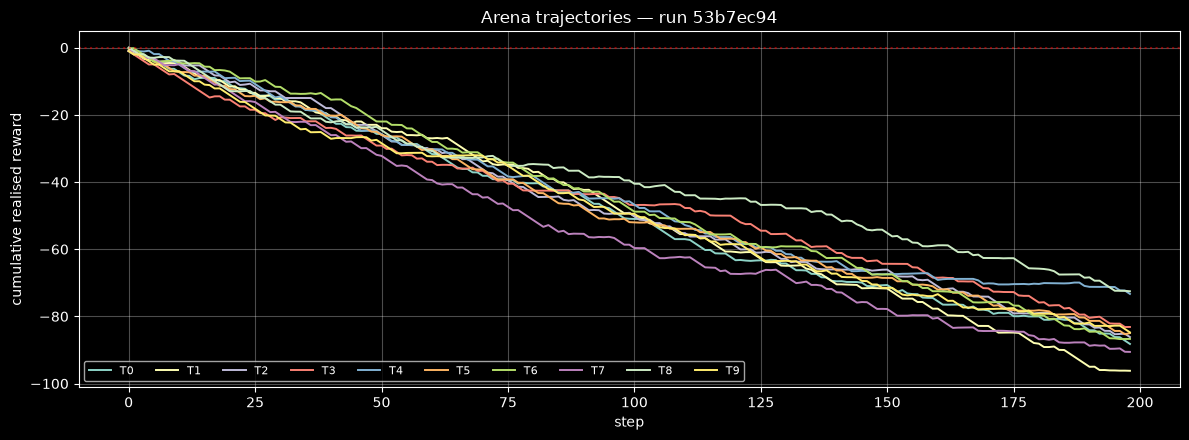

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for tid, gdf in df.groupby("trajectory_id"):
    gdf = gdf.sort_values("step_index")
    ax.plot(gdf.step_index, gdf.realized_reward.cumsum(), lw=1.4, label=f"T{tid}")
ax.axhline(0, color="red", ls=":", alpha=0.5)
ax.set_xlabel("step")
ax.set_ylabel("cumulative realised reward")
ax.set_title(f"Arena trajectories — run {latest.name[:8]}")
ax.legend(ncol=min(10, df.trajectory_id.nunique()), fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Super-state latent geometry

Load every `states/<traj>/<step>.npy` (the 260-d Chimera super-state + portfolio
features) and project the cloud with PCA. Drawing each trajectory's path in order
shows how trajectories share an origin and **diverge** through latent space — the
visual analogue of the divergence analyser.

Loaded 1990 super-states of dim 260


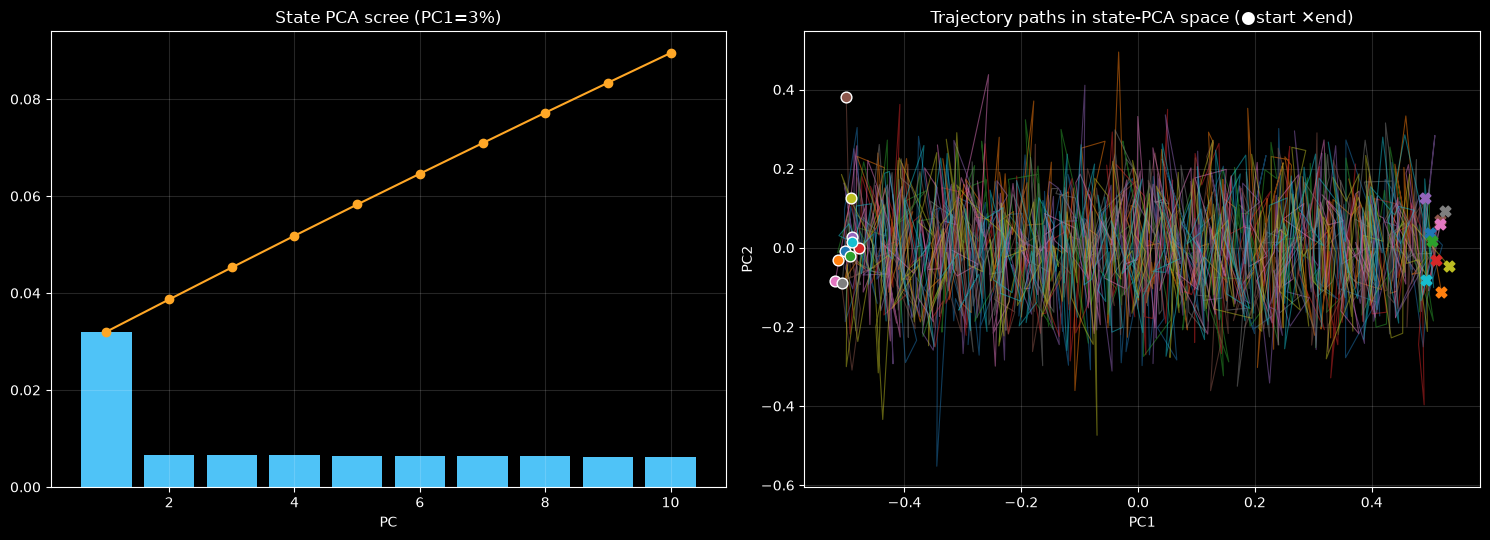

In [7]:
state_files = sorted(
    (latest / "states").rglob("*.npy"), key=lambda p: (int(p.parent.name), int(p.stem))
)
if state_files:
    S = np.stack([np.load(p) for p in state_files])
    tid_of = np.array([int(p.parent.name) for p in state_files])
    step_of = np.array([int(p.stem) for p in state_files])
    print(f"Loaded {S.shape[0]} super-states of dim {S.shape[1]}")

    pca = PCA(n_components=10).fit(S)
    S2 = pca.transform(S)[:, :2]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    axes[0].bar(range(1, 11), pca.explained_variance_ratio_, color=COLORS["primary"])
    axes[0].plot(
        range(1, 11), np.cumsum(pca.explained_variance_ratio_), "o-", color=COLORS["warning"]
    )
    axes[0].set_title(f"State PCA scree (PC1={pca.explained_variance_ratio_[0]:.0%})")
    axes[0].set_xlabel("PC")
    axes[0].grid(alpha=0.15)

    cmap = plt.colormaps.get_cmap("tab10")
    for tid in np.unique(tid_of):
        m = tid_of == tid
        o = np.argsort(step_of[m])
        xy = S2[m][o]
        axes[1].plot(xy[:, 0], xy[:, 1], "-", color=cmap(tid % 10), alpha=0.5, lw=0.8)
        axes[1].scatter(
            xy[0, 0], xy[0, 1], color=cmap(tid % 10), marker="o", s=60, edgecolor="white", zorder=5
        )
        axes[1].scatter(xy[-1, 0], xy[-1, 1], color=cmap(tid % 10), marker="X", s=60, zorder=5)
    axes[1].set_title("Trajectory paths in state-PCA space (●start ✕end)")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].grid(alpha=0.15)
    plt.tight_layout()
    plt.show()
else:
    print("No super-states on disk for this run.")

## 7. t-SNE of the super-state cloud

A non-linear view, coloured by trajectory. Clustering by trajectory means each
seed carves out its own region of latent space.

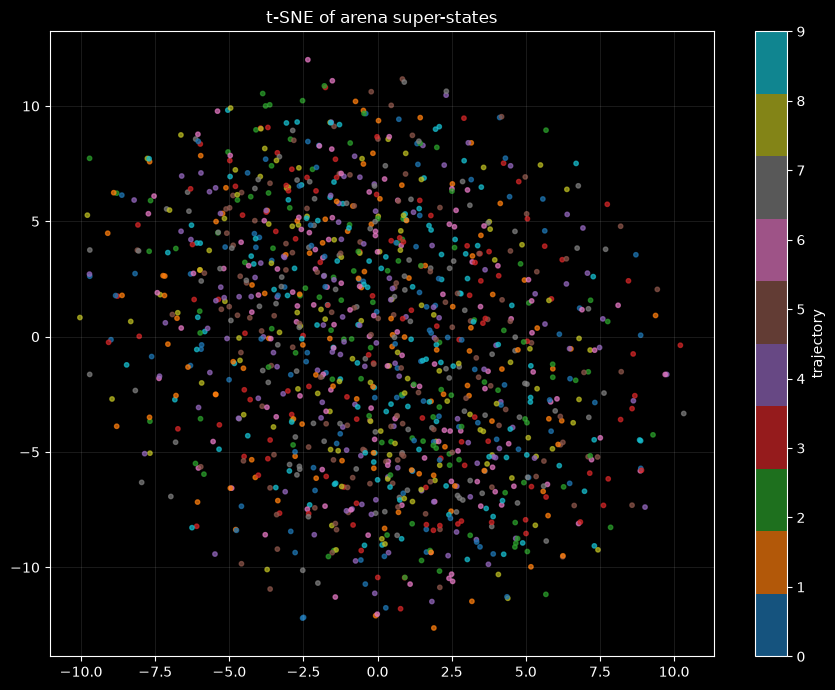

In [8]:
if state_files:
    sub = np.random.default_rng(0).choice(len(S), size=min(1200, len(S)), replace=False)
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(S[sub])
    plt.figure(figsize=(9, 7))
    sc = plt.scatter(emb[:, 0], emb[:, 1], c=tid_of[sub], cmap="tab10", s=10, alpha=0.7)
    plt.colorbar(sc, label="trajectory")
    plt.title("t-SNE of arena super-states")
    plt.grid(alpha=0.1)
    plt.tight_layout()
    plt.show()
else:
    print("No super-states to embed.")

## 8. Action-kind transition matrix

How the agent moves between BUY / SELL / HOLD / REDUCE / INCREASE from one step to
the next, row-normalised within each trajectory. (For an *untrained* run the
policy typically parks in a single kind — the frequencies printed below make any
such degeneracy obvious; on a trained run this matrix reveals real behavioural
dynamics.)

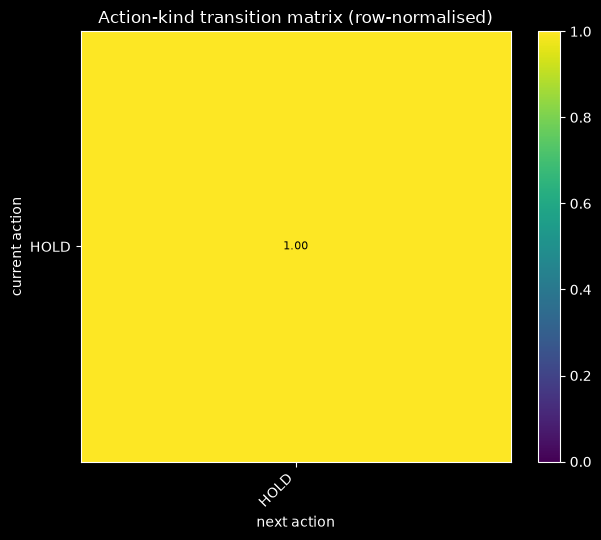

action-kind frequencies: {'HOLD': 1990}


In [9]:
kinds = ["BUY", "INCREASE", "HOLD", "REDUCE", "SELL"]
present = [k for k in kinds if k in set(df.action_kind)]
T = np.zeros((len(present), len(present)))
idx = {k: i for i, k in enumerate(present)}
for _, gdf in df.groupby("trajectory_id"):
    seq = gdf.sort_values("step_index")["action_kind"].tolist()
    for a, b in zip(seq, seq[1:]):
        if a in idx and b in idx:
            T[idx[a], idx[b]] += 1
Tn = T / T.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(Tn, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(present)))
ax.set_xticklabels(present, rotation=45, ha="right")
ax.set_yticks(range(len(present)))
ax.set_yticklabels(present)
for i in range(len(present)):
    for j in range(len(present)):
        ax.text(
            j,
            i,
            f"{Tn[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if Tn[i, j] < 0.6 else "black",
            fontsize=8,
        )
ax.set_xlabel("next action")
ax.set_ylabel("current action")
ax.set_title("Action-kind transition matrix (row-normalised)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print("action-kind frequencies:", df.action_kind.value_counts().to_dict())

## 9. Cross-modal weights & divergence proxy

Cross-modal weights should spread around ⅓ each; a modality stuck at 0 or 1 is a
red flag (here they are uniform — the untrained-pipeline signature). The
direction *spread* across trajectories per step is a cheap proxy for the
production divergence analyser (which additionally checks subsequent Sharpe and
lives in TimescaleDB).

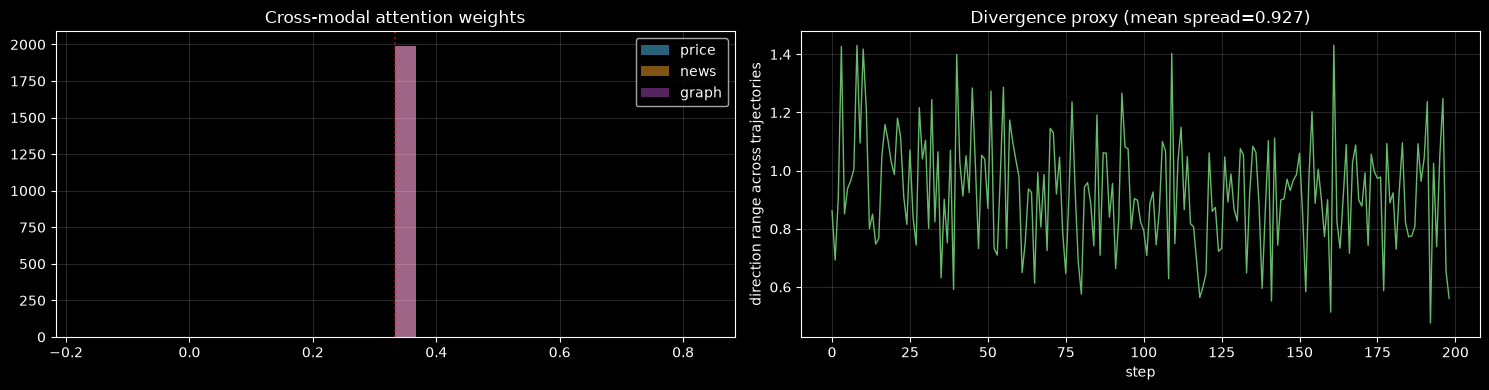

Most-divergent steps: {161: 1.431, 8: 1.431, 3: 1.427, 10: 1.418, 109: 1.403}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for col, c in [
    ("cm_price", COLORS["primary"]),
    ("cm_news", COLORS["warning"]),
    ("cm_graph", COLORS["accent"]),
]:
    axes[0].hist(df[col], bins=30, alpha=0.5, color=c, label=col.replace("cm_", ""))
axes[0].axvline(1 / 3, color="red", ls=":", alpha=0.6)
axes[0].set_title("Cross-modal attention weights")
axes[0].legend()
axes[0].grid(alpha=0.15)

spread = df.groupby("step_index")["direction"].agg(lambda s: s.max() - s.min())
axes[1].plot(spread.index, spread.values, color=COLORS["success"], lw=1)
axes[1].set_xlabel("step")
axes[1].set_ylabel("direction range across trajectories")
axes[1].set_title(f"Divergence proxy (mean spread={spread.mean():.3f})")
axes[1].grid(alpha=0.15)
plt.tight_layout()
plt.show()
print("Most-divergent steps:", spread.sort_values(ascending=False).head(5).round(3).to_dict())

## 10. Counterfactual / behaviour-cloning dataset

When the feedback pipeline has run, `bc_dataset.npz` holds `(state, action,
weight)` triples for the next BC phase — high-confidence counterfactuals get
larger weights. We show the action and weight distributions, and project the BC
states onto the run's PCA to see where the "good-action" states live.

BC dataset: states (597, 260), actions (597, 4), weights (597,)


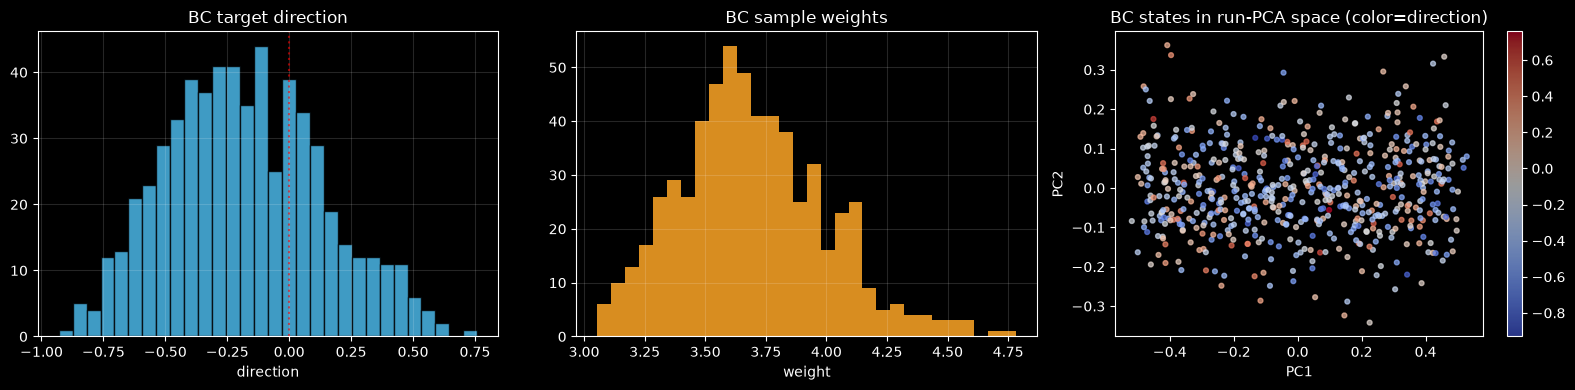

In [11]:
bc_path = artifact_root / "bc_dataset.npz"
if bc_path.exists():
    bc = np.load(bc_path)
    states_bc, actions_bc = bc["states"], bc["actions"]
    weights_bc = bc["weights"] if "weights" in bc else np.ones(len(actions_bc))
    print(
        f"BC dataset: states {states_bc.shape}, actions {actions_bc.shape}, weights {weights_bc.shape}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(actions_bc[:, 0], bins=30, color=COLORS["primary"], edgecolor="black", alpha=0.8)
    axes[0].axvline(0, color="red", ls=":", alpha=0.6)
    axes[0].set_title("BC target direction")
    axes[0].set_xlabel("direction")
    axes[0].grid(alpha=0.15)
    axes[1].hist(weights_bc, bins=30, color=COLORS["warning"], alpha=0.85)
    axes[1].set_title("BC sample weights")
    axes[1].set_xlabel("weight")
    axes[1].grid(alpha=0.15)
    if state_files and states_bc.shape[1] == S.shape[1]:
        bc2 = pca.transform(states_bc)[:, :2]
        sc = axes[2].scatter(
            bc2[:, 0], bc2[:, 1], c=actions_bc[:, 0], cmap="coolwarm", s=12, alpha=0.7
        )
        axes[2].set_title("BC states in run-PCA space (color=direction)")
        axes[2].set_xlabel("PC1")
        axes[2].set_ylabel("PC2")
        plt.colorbar(sc, ax=axes[2])
    else:
        axes[2].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"No bc_dataset.npz at {bc_path} — run the feedback pipeline to populate it.")

## 11. Run summary

Reuse the production `run_summarizer` to render the same narrative the API serves
at `/arena/runs/{run_id}/summary` — a round-trip check that the schema we loaded
survives the summariser.

In [12]:
by_traj: dict[int, list[DecisionRecord]] = {}
for r in records:
    by_traj.setdefault(r.trajectory_id, []).append(r)
n_traj = df.trajectory_id.nunique()
mc_seeds = [by_traj[t][0].mc_seed for t in sorted(by_traj)][:n_traj]
while len(mc_seeds) < 3:
    mc_seeds.append(0)
meta = ArenaRunMetadata(
    run_id=records[0].run_id,
    ticker=records[0].ticker,
    start_date=min(r.sim_timestamp for r in records),
    end_date=max(r.sim_timestamp for r in records),
    n_trajectories=max(3, n_traj),
    mc_seeds=mc_seeds,
)
summary = summarize_run(meta, by_traj, divergences=[])
print(summary.narrative)
print("\nsummary_method =", summary.summary_method)

Run 53b7ec94-434e-42dd-a870-ccdabeaef699 | ticker=AAPL | 1900-01-01 -> 1900-01-01 | N=10 trajectories
Performance: best=T8 (-229.01) | worst=T1 (-303.48) | mean=-264.71 | std=19.96
Divergences: total=0 | pivotal=0
Modality lean: most-frequent dominant = price (1990/1990 steps) | avg weights = price 0.33, news 0.33, graph 0.33

summary_method = template


## 12. Sanity assertions

In [13]:
assert df.trajectory_id.nunique() >= 2, "need ≥2 trajectories for divergence analysis"
assert df[["direction", "urgency", "sizing", "stop"]].notna().all().all()
totals = df[["cm_price", "cm_news", "cm_graph"]].sum(axis=1)
assert ((totals - 1.0).abs() < 1e-3).all(), "cross-modal weights must sum to 1"
assert df.confidence.between(0, 1).all() and df.uncertainty.between(0, 1).all()
if state_files:
    assert S.shape[1] == 260, f"unexpected super-state dim {S.shape[1]}"
    assert len(state_files) == len(records), "state/decision count mismatch"
print("PASS — arena run artifacts are well-formed and fully loadable.")

PASS — arena run artifacts are well-formed and fully loadable.
